In [2]:
# Import Libraries and packages
import yfinance as yf
import pandas as pd
import numpy as np

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Intro

**Weighted average cost of capital (WACC)** is a vital metric for assessing a company's financing costs by averaging the after-tax cost of all capital sources like equity and debt.

**WACC** is found by determining the proportions of debt and equity financing that a company uses to determine the total cost of capital. The equation is:

\begin{equation}\tag{WACC}
\mathrm{WACC} = \bigg(\frac{E}{V}\times R_e\bigg) + \bigg(\frac{D}{V}\times R_d\times (1 - T_c)\bigg)
\end{equation}

where
- $E$ = Market value of the firm’s equity
- $D$ = Market value of the firm’s debt
- $V = E + D$
- $R_e$ = Cost of equity
- $R_d$ = Cost of debt
- $T_c$ = Corporate tax rate

When companies reimburse bondholders, the amount they pay has a predetermined interest rate. 
On the other hand, equity has no concrete price that the company must pay. 
As a result, companies have to estimate the **cost of equity** (the rate of return that investors demand based on the expected volatility of the stock).

## CAPM

Companies typically use the **capital asset pricing model (CAPM)** to arrive at the cost of equity (in CAPM, it's called the expected return of investment). It’s important to note this calculation relies on past data, which can't precisely predict future growth.


The risk-free rate of return is typically estimated using the rate of return of short-term Treasury bills because these securities have stable values with guaranteed returns backed by the U.S. government. 

In [4]:
treasury_yield10 = yf.Ticker("^TNX") 
risk_free_rate = round(treasury_yield10.info['regularMarketPrice']/100,2) 

Now, we calculate the market expected return (we will assume the average return of the S&P500):

In [5]:
# Download S&P 500 historical data
sp500 = yf.download("^GSPC", start="2025-01-01", end="2026-03-02")

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

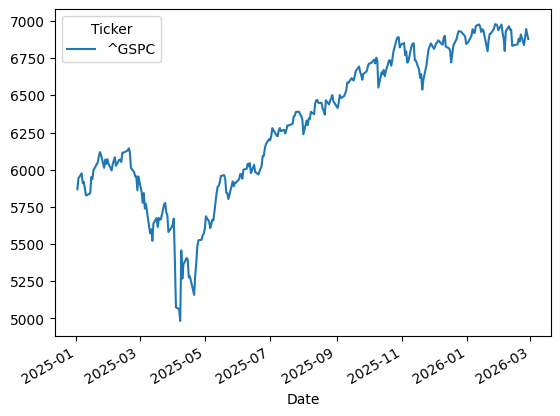

In [6]:
sp500.plot.line(y='Close', use_index=True)

In [8]:
# Calculate daily returns
daily_returns = sp500.Close.pct_change()

In [11]:
# Calculate average daily return and annualize it (252 trading days)
average_daily_return = daily_returns.mean()
sp500_teturn = (1 + average_daily_return)**252 - 1
# annualized_return = (1 + average_daily_return)**252 - 1

print(f"Average Annualized Return: {sp500_teturn.values[0]:.2%}")

Average Annualized Return: 16.77%


We calculate the beta of Microsoft:

In [12]:
beta = yf.Ticker('MSFT').info["beta"]

With all the information above, we can calculate the cost of equity:

In [13]:
cost_of_equity = round(risk_free_rate + beta*(sp500_teturn - risk_free_rate),2)
cost_of_equity

Ticker
^GSPC    0.18
dtype: float64

Using this method of estimating the cost of equity capital enables businesses to determine the most cost-effective means of raising funds, thereby minimizing the total cost of capital. From the perspective of the investor, the results can help decide whether the expected return justifies investment given the potential risk.

## References

- [Calculate Weighted Average Cost of Capital (WACC) Using Python](https://python.plainenglish.io/calculate-weighted-average-cost-of-capital-wacc-using-python-99ddc3c396c8)
- [Predict The Stock Market With Machine Learning And Python](https://www.youtube.com/watch?v=1O_BenficgE&t=74s)
- [How Does Market Risk Affect Cost of Capital?](https://www.investopedia.com/ask/answers/043015/how-does-market-risk-affect-cost-capital.asp?)
- [Cost of Capital and Capital Allocation](https://www.morganstanley.com/im/publication/insights/articles/article_costofcapitalandcapitalallocation.pdf)